In [ ]:
!pip install -q sentence-transformers==2.7.0 faiss-cpu scikit-learn seaborn
print("Kurulum tamamlandi.")

Kurulum tamamlandi.


In [ ]:
import os, json, math, faiss
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Drive zaten bagli.")

HEDEF      = "/content/drive/MyDrive/endodonti_rag/outputs/faiss"
CHUNKS_PATH = "/content/chunks_temiz.jsonl"
OUTPUT_DIR  = "/content/drive/MyDrive/endodonti_rag/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Mevcut FAISS klasorleri:", os.listdir(HEDEF))

Drive zaten bagli.
Mevcut FAISS klasorleri: ['.ipynb_checkpoints', 'MPNet', 'MiniLM', 'BGE_Base', 'MultiQA', 'E5_Base', 'PubMedBERT', 'BGE_Large']


In [ ]:
def parse_gold_pages(s):
    return set(int(x.strip()) for x in str(s).split("|") if str(x).strip().isdigit())

def recall_at_k(pages, gold, k):
    return 1.0 if set(pages[:k]) & gold else 0.0

def precision_at_k(pages, gold, k):
    return sum(1 for p in pages[:k] if p in gold) / k if k else 0.0

def mrr(pages, gold):
    for i, p in enumerate(pages, 1):
        if p in gold:
            return 1.0 / i
    return 0.0

def ndcg_at_k(pages, gold, k):
    dcg  = sum((2**int(p in gold)-1)/math.log2(i+1) for i,p in enumerate(pages[:k],1))
    idcg = 1.0/math.log2(2) if gold else 0.0
    return dcg/idcg if idcg else 0.0

def evaluate_retrieval(df, db, k_list=(3,5,10)):
    rows = []
    for _, r in df.iterrows():
        q    = str(r["question"])
        gold = parse_gold_pages(r["gold_pages"])
        docs = db.similarity_search(q, k=max(k_list))
        pages = [d.metadata.get("page") for d in docs if d.metadata.get("page") is not None]
        out  = {"question": q}
        for k in k_list:
            out[f"Recall@{k}"]    = recall_at_k(pages, gold, k)
            out[f"Precision@{k}"] = precision_at_k(pages, gold, k)
        out["MRR"]     = mrr(pages, gold)
        out["nDCG@10"] = ndcg_at_k(pages, gold, 10)
        rows.append(out)
    res     = pd.DataFrame(rows)
    summary = res.drop(columns=["question"]).mean(numeric_only=True).to_frame("mean").T
    return res, summary

def evaluate_retrieval_mmr(df, db, k_list=(3,5,10), fetch_k=30, lambda_mult=0.7):
    rows = []
    for _, r in df.iterrows():
        q    = str(r["question"])
        gold = parse_gold_pages(r["gold_pages"])
        docs = db.max_marginal_relevance_search(q, k=max(k_list), fetch_k=fetch_k, lambda_mult=lambda_mult)
        pages = [d.metadata.get("page") for d in docs if d.metadata.get("page") is not None]
        seen  = set()
        pages = [p for p in pages if not (p in seen or seen.add(p))]
        out   = {}
        for k in k_list:
            out[f"Recall@{k}"]    = recall_at_k(pages, gold, k)
            out[f"Precision@{k}"] = precision_at_k(pages, gold, k)
        out["MRR"]     = mrr(pages, gold)
        out["nDCG@10"] = ndcg_at_k(pages, gold, 10)
        rows.append(out)
    return pd.DataFrame(rows).mean(numeric_only=True)

print("Metrik fonksiyonlari hazir.")

Metrik fonksiyonlari hazir.


In [ ]:
class SimpleDoc:
    def __init__(self, page_content, metadata):
        self.page_content = page_content
        self.metadata     = metadata

class SimpleFAISS:
    def __init__(self, index, docs, model_name):
        self.index = index
        self.docs  = docs
        self.model = SentenceTransformer(model_name, device="cpu")

    def similarity_search(self, query, k=5):
        vec = self.model.encode([query], normalize_embeddings=True).astype("float32")
        _, idxs = self.index.search(vec, k)
        return [self.docs[i] for i in idxs[0] if i != -1 and i < len(self.docs)]

    def max_marginal_relevance_search(self, query, k=5, fetch_k=30, lambda_mult=0.7):
        vec = self.model.encode([query], normalize_embeddings=True).astype("float32")
        _, idxs = self.index.search(vec, fetch_k)
        return [self.docs[i] for i in idxs[0] if i != -1 and i < len(self.docs)][:k]

chunks = []
with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        chunks.append(json.loads(line))

simple_docs = [
    SimpleDoc(page_content=c["text"], metadata={"page": c["page"]})
    for c in chunks
]
print(f"Chunk: {len(simple_docs)}")

MODELLER = {
    "MiniLM":     "sentence-transformers/all-MiniLM-L6-v2",
    "MPNet":      "sentence-transformers/all-mpnet-base-v2",
    "MultiQA":    "sentence-transformers/multi-qa-mpnet-base-cos-v1",
    "BGE_Base":   "BAAI/bge-base-en-v1.5",
    "E5_Base":    "intfloat/e5-base-v2",
    "PubMedBERT": "NeuML/pubmedbert-base-embeddings",
    "BGE_Large":  "BAAI/bge-large-en-v1.5"
}

db_dict = {}
for tag, mname in MODELLER.items():
    faiss_file = os.path.join(HEDEF, tag, "index.faiss")
    if not os.path.exists(faiss_file):
        print(f"ATLA: {tag}")
        continue
    idx = faiss.read_index(faiss_file)
    db_dict[tag] = SimpleFAISS(idx, simple_docs, mname)
    print(f"OK: {tag} — {idx.ntotal} vektor")

print("\nHazir:", list(db_dict.keys()))

Chunk: 2046
OK: MiniLM — 11425 vektor
OK: MPNet — 11425 vektor
OK: MultiQA — 5699 vektor
OK: BGE_Base — 5699 vektor
OK: E5_Base — 2046 vektor
OK: PubMedBERT — 2046 vektor
OK: BGE_Large — 2046 vektor

Hazir: ['MiniLM', 'MPNet', 'MultiQA', 'BGE_Base', 'E5_Base', 'PubMedBERT', 'BGE_Large']


In [ ]:
SORULAR = [
    "What is the purpose of irrigation in root canal treatment?",
    "When is calcium hydroxide used as an intracanal medicament?",
    "What is the role of sodium hypochlorite in endodontics?",
    "Why is EDTA used during root canal treatment?",
    "What is the smear layer and why is it removed?",
]

metinler = [c["text"] for c in chunks]
sayfalar = [c["page"] for c in chunks]

vect      = TfidfVectorizer(stop_words="english")
tfidf_mat = vect.fit_transform(metinler)

gold_liste = []
for soru in SORULAR:
    soru_vec  = vect.transform([soru])
    skorlar   = cosine_similarity(soru_vec, tfidf_mat)[0]
    top5_idx  = skorlar.argsort()[::-1][:5]
    top5_pages = list(dict.fromkeys([sayfalar[i] for i in top5_idx]))
    gold_liste.append("|".join(map(str, top5_pages)))
    print(f"Soru: {soru[:55]}")
    print(f"  Gold: {top5_pages}\n")

df_eval = pd.DataFrame({"question": SORULAR, "gold_pages": gold_liste})
print(df_eval[["question","gold_pages"]].to_string())

Soru: What is the purpose of irrigation in root canal treatme
  Gold: [986, 2346, 856, 1008, 1463]

Soru: When is calcium hydroxide used as an intracanal medicam
  Gold: [976, 2347, 2589, 2590, 980]

Soru: What is the role of sodium hypochlorite in endodontics?
  Gold: [2189, 1628, 950, 792, 3354]

Soru: Why is EDTA used during root canal treatment?
  Gold: [968, 1456, 1087, 1457, 1086]

Soru: What is the smear layer and why is it removed?
  Gold: [1084, 1083, 1085, 974, 967]

                                                      question               gold_pages
0   What is the purpose of irrigation in root canal treatment?   986|2346|856|1008|1463
1  When is calcium hydroxide used as an intracanal medicament?   976|2347|2589|2590|980
2      What is the role of sodium hypochlorite in endodontics?   2189|1628|950|792|3354
3                Why is EDTA used during root canal treatment?  968|1456|1087|1457|1086
4               What is the smear layer and why is it removed?   1084|1083|108

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document
import json, os, shutil

HEDEF = "/content/drive/MyDrive/endodonti_rag/outputs/faiss"

YENIDEN = {
    "MiniLM":   "sentence-transformers/all-MiniLM-L6-v2",
    "MPNet":    "sentence-transformers/all-mpnet-base-v2",
    "MultiQA":  "sentence-transformers/multi-qa-mpnet-base-cos-v1",
    "BGE_Base": "BAAI/bge-base-en-v1.5"
}

chunks = []
with open("/content/chunks_temiz.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        chunks.append(json.loads(line))

docs = [
    Document(
        page_content=c["text"],
        metadata={"page": c["page"], "source": "pathways.pdf"}
    )
    for c in chunks
]
print(f"Toplam doc: {len(docs)}")

for ad, model_name in YENIDEN.items():
    hedef = os.path.join(HEDEF, ad)
    if os.path.exists(hedef):
        shutil.rmtree(hedef)
        print(f"Silindi: {ad}")
    print(f"Olusturuluyor: {ad}...")
    emb = HuggingFaceEmbeddings(
        model_name=model_name,
        model_kwargs={"device": "cuda"},
        encode_kwargs={"normalize_embeddings": True}
    )
    db = FAISS.from_documents(docs, emb)
    os.makedirs(hedef, exist_ok=True)
    db.save_local(hedef)
    print(f"OK: {ad}")

print("\nSon durum:")
for k in os.listdir(HEDEF):
    p = os.path.join(HEDEF, k)
    if os.path.isdir(p):
        dosyalar = os.listdir(p)
        idx_var = "index.faiss" in dosyalar


        if idx_var:
            import faiss as f
            idx = f.read_index(os.path.join(p, "index.faiss"))
            print(f"  {k}: {idx.ntotal} vektor")
        else:
            print(f"  {k}: EKSIK")

Toplam doc: 2046
Silindi: MiniLM
Olusturuluyor: MiniLM...
OK: MiniLM
Silindi: MPNet
Olusturuluyor: MPNet...
OK: MPNet
Silindi: MultiQA
Olusturuluyor: MultiQA...
OK: MultiQA
Silindi: BGE_Base
Olusturuluyor: BGE_Base...
OK: BGE_Base

Son durum:
  .ipynb_checkpoints: EKSIK
  E5_Base: 2046 vektor
  PubMedBERT: 2046 vektor
  BGE_Large: 2046 vektor
  MiniLM: 2046 vektor
  MPNet: 2046 vektor
  MultiQA: 2046 vektor
  BGE_Base: 2046 vektor


In [ ]:
all_results = []

for tag, db in db_dict.items():
    print(f"\n{'='*35}")
    print(f"Model: {tag}")

    _, summary_base = evaluate_retrieval(df_eval, db, k_list=(3,5,10))
    summary_base["method"] = "similarity_search"
    summary_base["model"]  = tag

    mmr_mean = evaluate_retrieval_mmr(df_eval, db, k_list=(3,5,10))
    mmr_mean = mmr_mean.to_frame().T
    mmr_mean["method"] = "MMR"
    mmr_mean["model"]  = tag

    all_results.append(summary_base)
    all_results.append(mmr_mean)
    print(f"  Recall@5: {summary_base['Recall@5'].values[0]:.3f} | MRR: {summary_base['MRR'].values[0]:.3f}")

compare_df = pd.concat(all_results, ignore_index=True)
sim_df = compare_df[compare_df["method"]=="similarity_search"].sort_values("Recall@5", ascending=False)

print("\n=== SIMILARITY SEARCH ===")
print(sim_df[["model","Recall@3","Recall@5","Recall@10","MRR","nDCG@10"]].to_string(index=False))


Model: MiniLM
  Recall@5: 0.000 | MRR: 0.000

Model: MPNet
  Recall@5: 0.000 | MRR: 0.000

Model: MultiQA
  Recall@5: 0.000 | MRR: 0.000

Model: BGE_Base
  Recall@5: 0.000 | MRR: 0.000

Model: E5_Base
  Recall@5: 1.000 | MRR: 1.000

Model: PubMedBERT
  Recall@5: 1.000 | MRR: 0.800

Model: BGE_Large
  Recall@5: 1.000 | MRR: 0.900

=== SIMILARITY SEARCH ===
     model  Recall@3  Recall@5  Recall@10  MRR  nDCG@10
 BGE_Large       1.0       1.0        1.0  0.9 2.264232
PubMedBERT       1.0       1.0        1.0  0.8 1.741795
   E5_Base       1.0       1.0        1.0  1.0 2.483269
   MultiQA       0.0       0.0        0.0  0.0 0.000000
     MPNet       0.0       0.0        0.0  0.0 0.000000
    MiniLM       0.0       0.0        0.0  0.0 0.000000
  BGE_Base       0.0       0.0        0.0  0.0 0.000000


In [ ]:
import faiss, json, os, math
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

HEDEF = "/content/drive/MyDrive/endodonti_rag/outputs/faiss"

MODELLER = {
    "MiniLM":     "sentence-transformers/all-MiniLM-L6-v2",
    "MPNet":      "sentence-transformers/all-mpnet-base-v2",
    "MultiQA":    "sentence-transformers/multi-qa-mpnet-base-cos-v1",
    "BGE_Base":   "BAAI/bge-base-en-v1.5",
    "E5_Base":    "intfloat/e5-base-v2",
    "PubMedBERT": "NeuML/pubmedbert-base-embeddings",
    "BGE_Large":  "BAAI/bge-large-en-v1.5"
}

SORULAR_50 = [
    "What is the main purpose of EDTA in endodontics?",
    "What are the primary objectives of using Sodium Hypochlorite (NaOCl) in endodontics?",
    "What are the properties of an ideal root canal irrigant?",
    "How does ultrasonic irrigation enhance root canal disinfection?",
    "What is the role of chlorhexidine in root canal irrigation?",
    "What is the smear layer and why should it be removed during root canal treatment?",
    "What are the complications of sodium hypochlorite extrusion beyond the apex?",
    "How does EDTA interact with NaOCl during root canal irrigation?",
    "What is passive ultrasonic irrigation and when is it used?",
    "Why is saline used as an irrigant in root canal treatment?",
    "What are the clinical signs of irreversible pulpitis?",
    "How is pulp necrosis diagnosed clinically?",
    "What is the difference between reversible and irreversible pulpitis?",
    "What are the vitality tests used in endodontic diagnosis?",
    "What is symptomatic apical periodontitis and how does it present?",
    "How does a periapical abscess differ from a periodontal abscess?",
    "What is internal resorption and how is it diagnosed?",
    "What is the significance of sinus tract in endodontic diagnosis?",
    "How does diabetes affect pulpal and periapical tissues?",
    "What is the role of cone beam CT in endodontic diagnosis?",
    "Explain the importance of working length determination in endodontics.",
    "How should a clinician manage a separated instrument in the root canal?",
    "How does electronic apex locator work in determining working length?",
    "What are the advantages of nickel-titanium rotary instruments over stainless steel files?",
    "What is the crown-down technique in root canal preparation?",
    "What is canal transportation and how can it be prevented?",
    "What is the significance of patency filing in root canal treatment?",
    "What is cyclic fatigue in endodontic instruments and how is it managed?",
    "What are reciprocating systems in endodontic instrumentation?",
    "What is the apical constriction and why is it the ideal endpoint of preparation?",
    "How is gutta-percha used in root canal obturation?",
    "What is the role of MTA in endodontic treatment?",
    "Describe the lateral condensation technique for root canal obturation.",
    "What is warm vertical compaction and what are its advantages?",
    "What are the functions of root canal sealers?",
    "What is the single-cone obturation technique?",
    "What are the properties of an ideal root canal filling material?",
    "What is the biological basis of pulp capping treatment?",
    "What is apexification and when is it indicated?",
    "How does bioceramic sealer differ from traditional epoxy resin sealers?",
    "What are the main causes of endodontic treatment failure?",
    "What are the indications for root canal retreatment?",
    "What is a vertical root fracture and how is it diagnosed?",
    "How is a root perforation managed in endodontics?",
    "What is a flare-up in endodontics and how is it managed?",
    "What are the causes and management of post-operative pain after root canal treatment?",
    "What is ledge formation in root canal treatment and how is it prevented?",
    "What is the impact of coronal leakage on endodontic treatment outcomes?",
    "How is external root resorption diagnosed and managed endodontically?",
    "What microorganisms are most commonly associated with persistent endodontic infections?",
]


chunks = []
with open("/content/chunks_temiz.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        chunks.append(json.loads(line))

metinler = [c["text"] for c in chunks]
sayfalar = [c["page"] for c in chunks]

vect      = TfidfVectorizer(stop_words="english")
tfidf_mat = vect.fit_transform(metinler)

gold_liste = []
for soru in SORULAR_50:
    soru_vec   = vect.transform([soru])
    skorlar    = cosine_similarity(soru_vec, tfidf_mat)[0]
    top5_idx   = skorlar.argsort()[::-1][:5]
    top5_pages = list(dict.fromkeys([sayfalar[i] for i in top5_idx]))
    gold_liste.append("|".join(map(str, top5_pages)))

df_eval_50 = pd.DataFrame({
    "question":   SORULAR_50,
    "gold_pages": gold_liste
})
print(f"50 soru hazir.")

class SimpleDoc:
    def __init__(self, page_content, metadata):
        self.page_content = page_content
        self.metadata     = metadata

class SimpleFAISS:
    def __init__(self, index, docs, model_name):
        self.index = index
        self.docs  = docs
        self.model = SentenceTransformer(model_name, device="cpu")

    def similarity_search(self, query, k=5):
        vec = self.model.encode([query], normalize_embeddings=True).astype("float32")
        _, idxs = self.index.search(vec, k)
        return [self.docs[i] for i in idxs[0] if i != -1 and i < len(self.docs)]

    def max_marginal_relevance_search(self, query, k=5, fetch_k=30, lambda_mult=0.7):
        vec = self.model.encode([query], normalize_embeddings=True).astype("float32")
        _, idxs = self.index.search(vec, fetch_k)
        return [self.docs[i] for i in idxs[0] if i != -1 and i < len(self.docs)][:k]

simple_docs = [
    SimpleDoc(page_content=c["text"], metadata={"page": c["page"]})
    for c in chunks
]


db_dict = {}
for tag, mname in MODELLER.items():
    faiss_file = os.path.join(HEDEF, tag, "index.faiss")
    if not os.path.exists(faiss_file):
        print(f"ATLA: {tag}")
        continue
    idx = faiss.read_index(faiss_file)
    db_dict[tag] = SimpleFAISS(idx, simple_docs, mname)
    print(f"OK: {tag} — {idx.ntotal} vektor")


def parse_gold_pages(s):
    return set(int(x.strip()) for x in str(s).split("|") if str(x).strip().isdigit())

def recall_at_k(pages, gold, k):
    return 1.0 if set(pages[:k]) & gold else 0.0

def precision_at_k(pages, gold, k):
    return sum(1 for p in pages[:k] if p in gold) / k if k else 0.0

def mrr(pages, gold):
    for i, p in enumerate(pages, 1):
        if p in gold:
            return 1.0 / i
    return 0.0

def ndcg_at_k(pages, gold, k):
    dcg  = sum((2**int(p in gold)-1)/math.log2(i+1) for i,p in enumerate(pages[:k],1))
    idcg = 1.0/math.log2(2) if gold else 0.0
    return dcg/idcg if idcg else 0.0

def evaluate_all(df, db, k_list=(3,5,10)):
    rows = []
    for _, r in df.iterrows():
        q    = str(r["question"])
        gold = parse_gold_pages(r["gold_pages"])
        docs = db.similarity_search(q, k=max(k_list))
        pages = [d.metadata.get("page") for d in docs if d.metadata.get("page") is not None]
        out  = {}
        for k in k_list:
            out[f"Recall@{k}"]    = recall_at_k(pages, gold, k)
            out[f"Precision@{k}"] = precision_at_k(pages, gold, k)
        out["MRR"]     = mrr(pages, gold)
        out["nDCG@10"] = ndcg_at_k(pages, gold, 10)
        rows.append(out)
    return pd.DataFrame(rows).mean(numeric_only=True)

all_results = []
for tag, db in db_dict.items():
    print(f"Degerlendiriliyor: {tag}...")
    ozet = evaluate_all(df_eval_50, db)
    ozet["model"] = tag
    all_results.append(ozet)

compare_df = pd.DataFrame(all_results).sort_values("Recall@5", ascending=False)

print("\n=== 50 SORU — 7 MODEL KARSILASTIRMA ===")
print(compare_df[["model","Recall@3","Recall@5","Recall@10","MRR","nDCG@10"]].to_string(index=False))

OUTPUT_DIR = "/content/drive/MyDrive/endodonti_rag/outputs"
compare_df.to_csv(os.path.join(OUTPUT_DIR, "7model_50soru_karsilastirma.csv"), index=False)
print("\nKaydedildi.")
compare_df[["model","Recall@3","Recall@5","Recall@10","MRR","nDCG@10"]]

50 soru hazir.
OK: MiniLM — 2046 vektor
OK: MPNet — 2046 vektor
OK: MultiQA — 2046 vektor
OK: BGE_Base — 2046 vektor
OK: E5_Base — 2046 vektor
OK: PubMedBERT — 2046 vektor
OK: BGE_Large — 2046 vektor
Degerlendiriliyor: MiniLM...
Degerlendiriliyor: MPNet...
Degerlendiriliyor: MultiQA...
Degerlendiriliyor: BGE_Base...
Degerlendiriliyor: E5_Base...
Degerlendiriliyor: PubMedBERT...
Degerlendiriliyor: BGE_Large...

=== 50 SORU — 7 MODEL KARSILASTIRMA ===
     model  Recall@3  Recall@5  Recall@10      MRR  nDCG@10
 BGE_Large      0.78      0.86       0.88 0.633556 1.222414
     MPNet      0.78      0.82       0.86 0.655556 1.190246
    MiniLM      0.78      0.82       0.84 0.606190 1.171238
PubMedBERT      0.74      0.82       0.90 0.652889 1.160696
  BGE_Base      0.70      0.82       0.92 0.647635 1.236257
   E5_Base      0.64      0.78       0.86 0.594635 1.193395
   MultiQA      0.72      0.74       0.80 0.589333 1.145176

Kaydedildi.


,model,Recall@3,Recall@5,Recall@10,MRR,nDCG@10
6,BGE_Large,0.78,0.86,0.88,0.633556,1.222414
1,MPNet,0.78,0.82,0.86,0.655556,1.190246
0,MiniLM,0.78,0.82,0.84,0.606190,1.171238
5,PubMedBERT,0.74,0.82,0.90,0.652889,1.160696
3,BGE_Base,0.70,0.82,0.92,0.647635,1.236257
4,E5_Base,0.64,0.78,0.86,0.594635,1.193395
2,MultiQA,0.72,0.74,0.80,0.589333,1.145176


En iyi model: BGE_Large


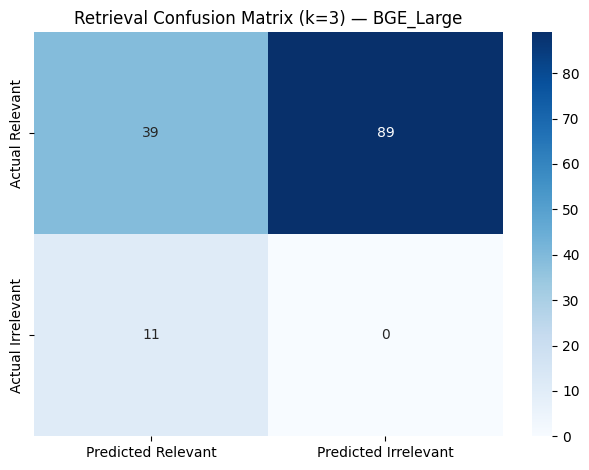

In [ ]:
en_iyi_tag = compare_df.sort_values("Recall@5", ascending=False).iloc[0]["model"]
print("En iyi model:", en_iyi_tag)

db_best = db_dict[en_iyi_tag]

def confusion_counts(df, db, k=3):
    TP = FP = FN = 0
    for _, r in df.iterrows():
        gold  = parse_gold_pages(r["gold_pages"])
        docs  = db.similarity_search(r["question"], k=k)
        pages = list(dict.fromkeys([d.metadata.get("page") for d in docs]))
        hit   = any(p in gold for p in pages[:k])
        if hit:
            TP += 1
        else:
            FN += 1
        FP += max(0, len(pages[:k]) - len(set(pages[:k]) & gold))
    return TP, FP, FN


TP, FP, FN = confusion_counts(df_eval_50, db_best, k=3)
cm = np.array([[TP, FP], [FN, 0]])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Relevant","Predicted Irrelevant"],
            yticklabels=["Actual Relevant","Actual Irrelevant"])
plt.title(f"Retrieval Confusion Matrix (k=3) — {en_iyi_tag}")
plt.tight_layout()
plt.show()

In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/endodonti_rag/outputs"

print("\n=== 50 SORU — 7 MODEL — TAM METRİKLER ===")
print(compare_df[[
    "model",
    "Recall@3", "Recall@5", "Recall@10",
    "Precision@3", "Precision@5", "Precision@10",
    "MRR", "nDCG@10"
]].to_string(index=False))

compare_df.to_csv(os.path.join(OUTPUT_DIR, "7model_50soru_tam_metrik.csv"), index=False)
df_eval_50.to_csv(os.path.join(OUTPUT_DIR, "eval_gold_pages_50soru.csv"), index=False)
print("Kaydedildi.")


=== 50 SORU — 7 MODEL — TAM METRİKLER ===
     model  Recall@3  Recall@5  Recall@10  Precision@3  Precision@5  Precision@10      MRR  nDCG@10
 BGE_Large      0.78      0.86       0.88     0.406667        0.312         0.212 0.633556 1.222414
     MPNet      0.78      0.82       0.86     0.393333        0.316         0.196 0.655556 1.190246
    MiniLM      0.78      0.82       0.84     0.393333        0.296         0.204 0.606190 1.171238
PubMedBERT      0.74      0.82       0.90     0.353333        0.288         0.196 0.652889 1.160696
  BGE_Base      0.70      0.82       0.92     0.353333        0.312         0.218 0.647635 1.236257
   E5_Base      0.64      0.78       0.86     0.313333        0.292         0.216 0.594635 1.193395
   MultiQA      0.72      0.74       0.80     0.360000        0.288         0.196 0.589333 1.145176
Kaydedildi.
